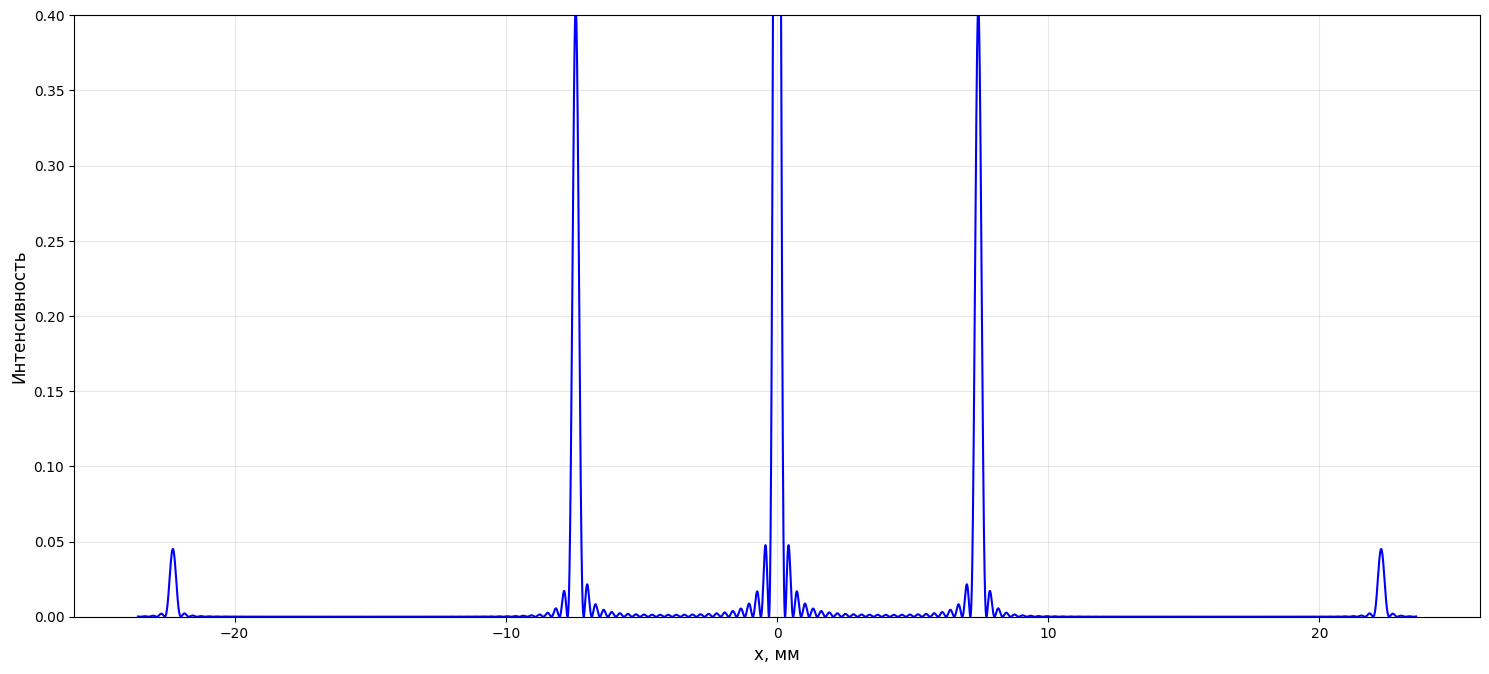

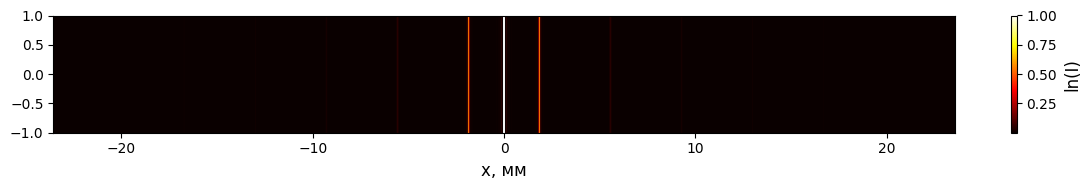

Параметры решетки:
Длина волны: 550.0 нм
Ширина щели: 100.0 мкм
Период решетки: 200.0 мкм
Число щелей: 25
Угловое положение максимумов 1-го порядка: ±0.16°


In [15]:
#убрать лог масштаб, меньше максимумов

# Параметры решетки
lambda_wave = 550e-9  # Длина волны (500 нм)
L=2700
b = 100e-6             # Ширина щели (мкм)
d = 200e-6             # Период решетки (мкм)
N = 25               # Число щелей
A = 1     # Амплитуда

# Углы наблюдения
theta = np.linspace(-np.pi/30/3/4, np.pi/30/3/4, 10000)
distance= theta*L

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def diffraction_grating_intensity(theta, m, b, A, N, d, lambda_wave):
    """
    Вычисление интенсивности дифракционной картины для решетки
    
    Параметры:
    theta - угол наблюдения (в радианах)
    m - порядок дифракции
    b - ширина щели
    A - параметр (обычно связан с длиной волны)
    N - число щелей
    d - период решетки
    lambda_wave - длина волны
    """
    
    # Первый множитель - дифракция на одной щели
    alpha = np.pi * b * np.sin(theta) / lambda_wave
    single_slit = (np.sin(alpha) / alpha) ** 2
    single_slit = np.where(np.isnan(single_slit), 1.0, single_slit)  # Устраняем деление на 0
    
    # Второй множитель - интерференция от N щелей
    beta = np.pi * d * np.sin(theta) / lambda_wave
    multi_slit = (np.sin(N * beta) / np.sin(beta)) ** 2
    multi_slit = np.where(np.isnan(multi_slit), N**2, multi_slit)  # Устраняем деление на 0
    
    # Общая интенсивность
    intensity = single_slit * multi_slit
    
    return intensity


# Вычисление интенсивности
intensity = diffraction_grating_intensity(theta, 1, b, A, N, d, lambda_wave)

# Нормализация интенсивности
intensity = intensity / np.max(intensity)

# Создание графиков
fig = plt.figure(figsize=(15, 10))
gs = GridSpec(2, 1, height_ratios=[2, 1])

# Основной график дифракционной картины
ax1 = fig.add_subplot(gs[0])
ax1.set_ylim(top=0.4)
ax1.plot(distance, intensity, 'b-', linewidth=1.5)
ax1.set_xlabel('x, мм', fontsize=12)
ax1.set_ylabel('Интенсивность', fontsize=12)
ax1.grid(True, alpha=0.3)

# Увеличенный вид центральной области
#ax2 = fig.add_subplot(gs[1])
#ax2.plot(np.degrees(theta), intensity, 'r-', linewidth=1.5)
##ax2.set_xlabel('Угол (градусы)', fontsize=12)
#ax2.set_ylabel('Логарифм интенсивности', fontsize=12)
#ax2.set_title('Центральная область (увеличенный вид)', fontsize=14)
#ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Дополнительная визуализация: 2D картина дифракции
fig, ax = plt.subplots(figsize=(12, 2))

# Создание 2D представления
X = np.linspace(-np.pi/30/3, np.pi/30/3, 1000)
Y = np.linspace(-1, 1, 500)
X, Y = np.meshgrid(X, Y)

# Интенсивность для 2D отображения
intensity_2d = diffraction_grating_intensity(X, 1, b, A, N, d, lambda_wave)
intensity_2d = intensity_2d / np.max(intensity_2d)

# Отображение 2D картины
im = ax.imshow(intensity_2d, extent=[distance.min(), distance.max(), Y.min(), Y.max()], 
               cmap='hot', aspect='auto', origin='lower',)
ax.set_xlabel('x, мм', fontsize=12)

# Добавление цветовой шкалы
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('ln(I)', fontsize=12)

plt.tight_layout()
plt.show()

# Вывод информации о параметрах
print("Параметры решетки:")
print(f"Длина волны: {lambda_wave*1e9:.1f} нм")
print(f"Ширина щели: {b*1e6:.1f} мкм")
print(f"Период решетки: {d*1e6:.1f} мкм")
print(f"Число щелей: {N}")
print(f"Угловое положение максимумов 1-го порядка: ±{np.degrees(np.arcsin(lambda_wave/d)):.2f}°")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def error_of_exp(x_exp, y_exp, flag=0):
    """
    Calculating errors of linear coefficients in experiment
    :param x_exp: list -- experimental data (x-coordinate)
    :param y_exp: list -- experimental data (y-coordinate)
    :param flag: int -- if flag == 0 function will print errors of linear coefficients in experiment
    :return: er_k, er_b -- float -- errors of linear coefficients in experiment
    """
    x_exp=np.array(x_exp)
    y_exp=np.array(y_exp)
    coefficient = np.polyfit(x_exp, y_exp, 1)
    k, b = coefficient[0], coefficient[1]
    av_x = 0
    for _ in range(len(x_exp)):
        av_x += x_exp[_]
    av_x = av_x / len(x_exp)

    av_y = 0
    for _ in range(len(y_exp)):
        av_y += y_exp[_]
    av_y = av_y / len(y_exp)

    D_x = 0
    for _ in range(len(x_exp)):
        D_x += (x_exp[_] - av_x)**2
    D_x = D_x / len(x_exp)

    D_y = 0
    for _ in range(len(y_exp)):
        D_y += (y_exp[_] - av_y) ** 2
    D_y = D_y / len(y_exp)

    av_x2 = 0
    for _ in range(len(x_exp)):
        av_x2 += x_exp[_]**2
    av_x2 = av_x2 / len(x_exp)

    er_k = np.sqrt(1/(len(x_exp)-2)*((D_y/D_x)-k**2))
    er_b = er_k * np.sqrt(av_x2)
    if flag == 0:
        print('Coefficions calculeted in linear approximation:')
        print("k = ", k, "+-", er_k)
        print("b = ", b, "+-", er_b)
    if flag == 1:
        return er_k, er_b
    if flag == 2:
        return k, b
def linear_theory(x_exp, y_exp, m = None, M = None):
    """
    :param x_exp: list -- experimental data for x-axis
    :param y_exp: list -- experimental data for y-axis
    :return: x_th, y_th -- lists with linear approximation of experimental data
    :m -- minimal x_value
    :M -- maximal x_value
    """
    if m == None: m=min(x_exp)
    if M == None: M=max(x_exp)
    exp= pd.DataFrame({"x":x_exp,"y": y_exp})
    exp=exp[exp.x<=M]
    exp=exp[exp.x>=m]
    k, b = np.polyfit(exp.x, exp.y, 1)
    x_th = np.arange(m - 0.05 * (M - m), M + 0.05 * (M - m), 0.0001 * (M - m))
    y_th = []
    for _ in range(0, len(x_th)):
        y_th.append(k * x_th[_] + b)
    y_th=np.array(y_th)
    error_of_exp(exp.x,exp.y)
    return pd.DataFrame(np.array([x_th, y_th]).transpose(), columns=['x','y'])

def plot_setup(x_name, y_name):
    """
    Function for drawing plot with one curve of points (x_exp, y_exp) with linear approximation and error-bars
    :param x_name: string -- name for x-axis
    :param y_name: string -- name for x-axis
    """
    plt.figure(figsize=(10, 5))
    plt.xlabel(x_name, fontsize=14)
    plt.ylabel(y_name, fontsize=14)
    plt.grid(True)
def plot_show():
    plt.legend(loc='best', fontsize=12)
    plt.show()
def const_err(x_exp, y_exp, label="Эксперементальные точки", xerr=0, yerr=0):
    plt.errorbar(x_exp, y_exp, np.full(x_exp.size, xerr), np.full(y_exp.size, yerr), fmt=".", label=label)


In [5]:
ox=pd.read_excel("решетки.xlsx", sheet_name="oxidised")
unox=pd.read_excel("решетки.xlsx", sheet_name="unox")
ox["x"]=np.arange(-8.5*2,12.5*2,2)
ox=ox.iloc[:-1].copy()
print(ox)

ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.

In [ ]:
unox["x"]=np.arange(-7.5*2,12.5*2, 2)
unox=unox.iloc[:-1].copy()

In [ ]:
ox

,"dd, клет",n,Unnamed: 2,d,x
0,NaN,NaN,-120,-120.0,-17.0
1,14.0,-8.0,-106,-106.0,-15.0
2,14.0,-7.0,-92,-92.0,-13.0
3,14.0,-6.0,-78,-78.0,-11.0
4,14.0,-5.0,-64,-64.0,-9.0
5,14.0,-4.0,-50,-50.0,-7.0
6,14.0,-3.0,-36,-36.0,-5.0
7,15.0,-2.0,-21,-21.0,-3.0
8,14.0,-1.0,-7,-7.0,-1.0
9,7.0,0.0,0,7.0,1.0


Coefficions calculeted in linear approximation:
k =  7.177067669172935 +- 0.012221097234509107
b =  0.7958646616541105 +- 0.1430442757096546


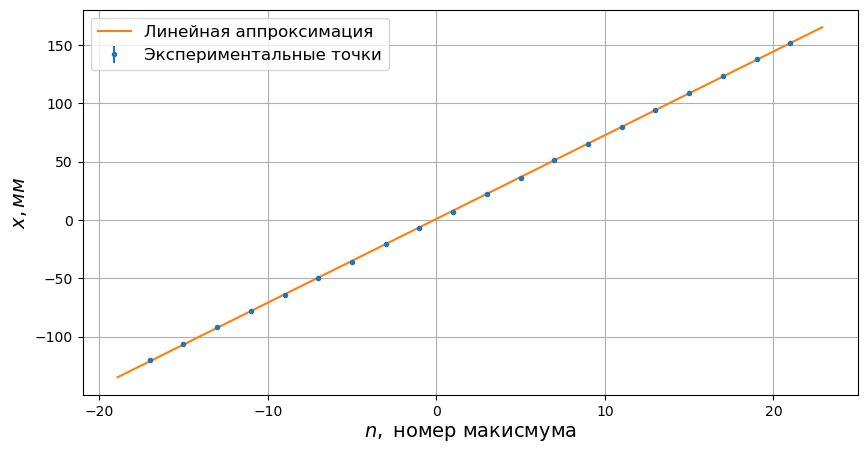

In [ ]:
plot_setup("$n,$ номер макисмума", "$x,мм$")
th=linear_theory(ox["x"],ox["d"])
plt.errorbar(ox["x"],ox["d"], yerr=1, fmt=".", label="Экспериментальные точки")
plt.plot(th.x, th.y, label="Линейная аппроксимация")
plot_show()

Coefficions calculeted in linear approximation:
k =  7.242982456140348 +- 0.013805855029076096
b =  1.2710526315789545 +- 0.15680437069105785


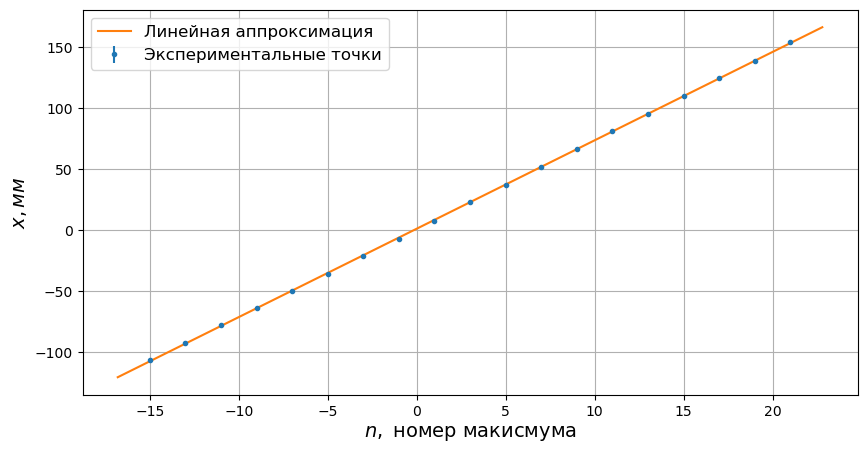

In [ ]:
plot_setup("$n,$ номер макисмума", "$x,мм$")
th=linear_theory(unox["x"],unox["d"])
plt.errorbar(unox["x"],unox["d"], yerr=1, fmt=".", label="Экспериментальные точки")
plt.plot(th.x, th.y, label="Линейная аппроксимация")
plot_show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageDraw, ImageFont
import numpy as np

def add_scale_bar(image_path, output_path, pixel_to_um, bar_length_um, 
                  bar_height=5, color='white', position='lower right', 
                  font_size=20):
    """
    Добавляет масштабную метку на микроскопическое изображение
    
    Args:
        image_path: путь к TIFF изображению
        output_path: путь для сохранения
        pixel_to_um: коэффициент пиксели -> микрометры
        bar_length_um: длина шкалы в микрометрах
        bar_height: высота шкалы в пикселях
        color: цвет шкалы и текста
        position: положение шкалы ('lower right', 'lower left', etc.)
    """
    
    # Загрузка изображения
    img = Image.open(image_path)
    img_array = np.array(img)
    
    # Создание рисунка
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(img_array, cmap='gray')
    ax.axis('off')
    
    # Расчет размеров шкалы в пикселях
    bar_length_pixels = bar_length_um / pixel_to_um
    
    # Определение позиции шкалы
    height, width = img_array.shape[:2]
    margin = 50  # отступ от края
    
    if position == 'lower right':
        x_start = width - bar_length_pixels - margin
        y_start = height - margin - bar_height
    elif position == 'lower left':
        x_start = margin
        y_start = height - margin - bar_height
    elif position == 'upper right':
        x_start = width - bar_length_pixels - margin
        y_start = margin
    elif position == 'upper left':
        x_start = margin
        y_start = margin
    else:
        x_start = width - bar_length_pixels - margin
        y_start = height - margin - bar_height
    
    # Добавление шкалы
    rect = patches.Rectangle((x_start, y_start), bar_length_pixels, bar_height,
                           linewidth=1, edgecolor=color, facecolor=color)
    ax.add_patch(rect)
    
    # Добавление текста
    text_x = x_start + bar_length_pixels / 2
    text_y = y_start - 10
    ax.text(text_x, text_y, f'{bar_length_um} μm', 
            color=color, fontsize=font_size, 
            ha='center', va='bottom', weight='bold')
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0)
    plt.close()

# Пример использования
add_scale_bar('ox_opt.tif', 'ox_opt_scale.jpeg', 
              pixel_to_um=1083/2048, bar_length_um=100)

In [ ]:
add_scale_bar('unox_opt.tif', 'unox_opt_scale.jpeg', 
              pixel_to_um=1083/2048, bar_length_um=100)

In [ ]:
add_scale_bar('lavygin_norm_full.tif', 'lavygin_norm_full_scale.jpeg', 
              pixel_to_um=1083/2048*8, bar_length_um=400, position="lower left")

In [ ]:
add_scale_bar('lavygin_ox_full.tif', 'lavygin_ox_full_scale.jpeg', 
              pixel_to_um=1083/2048*8, bar_length_um=400, position="lower left")